How to Approach Machine Learning Projects

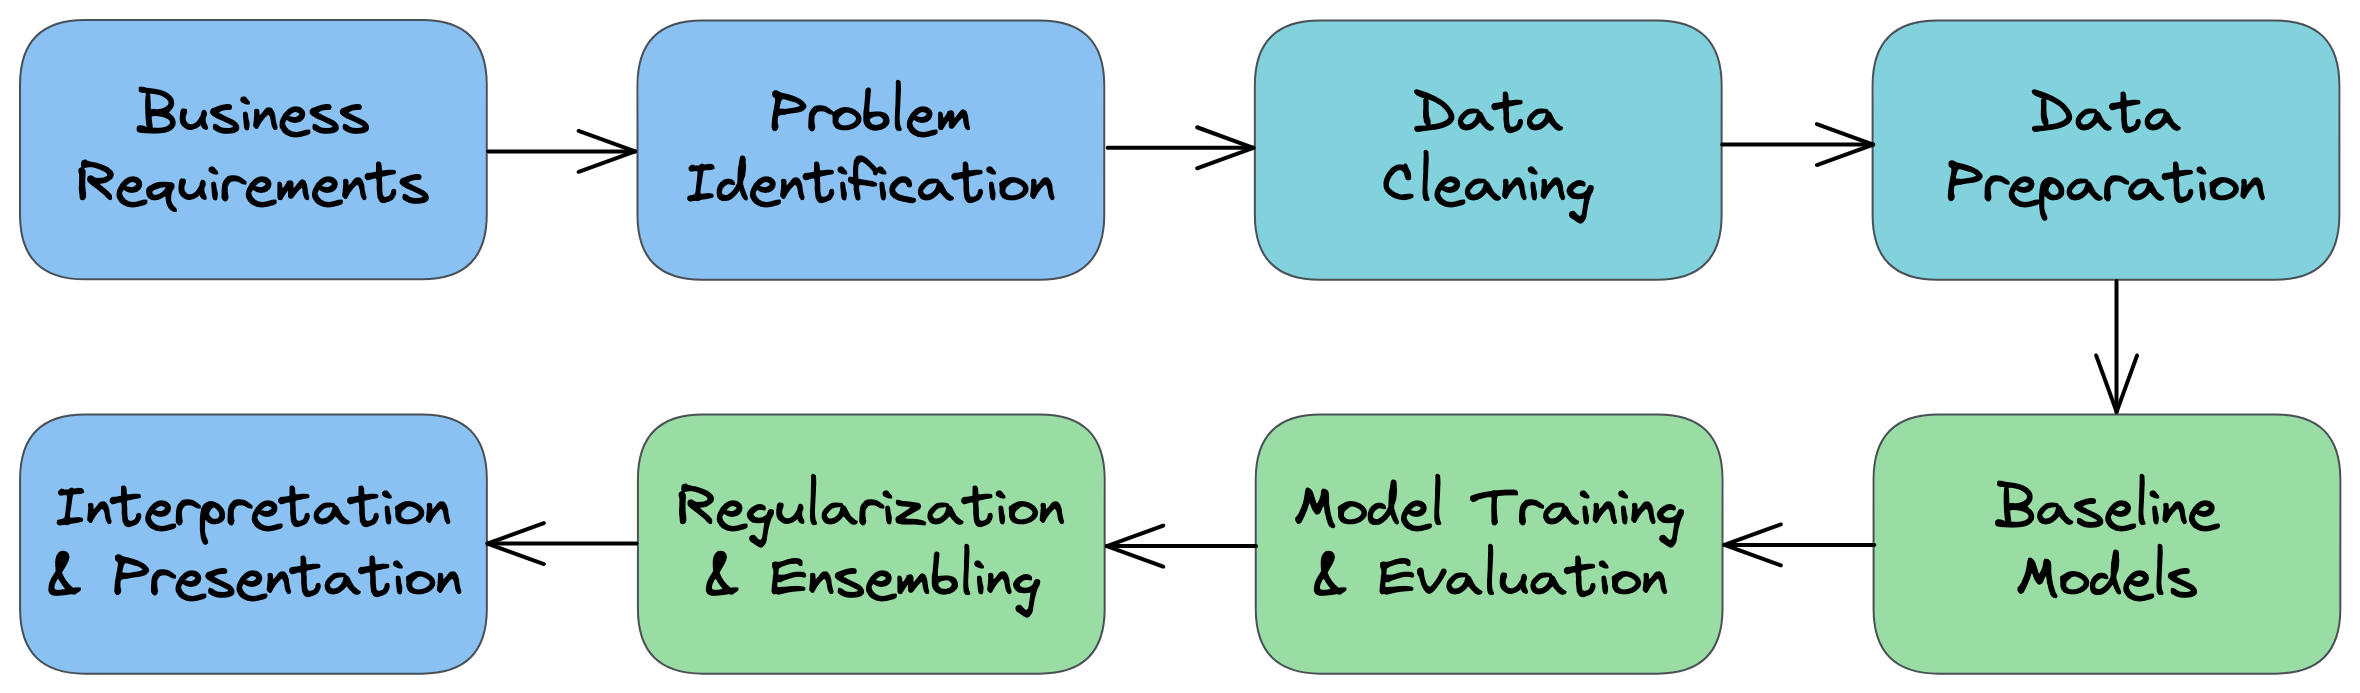

In this tutorial, we'll explore a step-by-step process for approaching ML problems:

1. Understand the business requirements and the nature of the available data.
2. Classify the problem as supervised/unsupervised and regression/classification.
3. Download, clean & explore the data and create new features that may improve models.
4. Create training/test/validation sets and prepare the data for training ML models.
5. Create a quick & easy baseline model to evaluate and benchmark future models.
6. Pick a modeling strategy, train a model, and tune hyperparameters to achieve optimal fit.
7. Experiment and combine results from multiple strategies to get a better result.
8. Interpret models, study individual predictions, and present your findings. 


In [1]:
%pip install numpy pandas-profiling matplotlib plotly seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install opendatasets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os 
import jovian
import matplotlib
import opendatasets as od
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

<IPython.core.display.Javascript object>

## Step 2 - 4Classify the problem as supervised/unsupervised & regression/classification

<img src="https://i.imgur.com/rqt2A7F.png" width="640">

Here's the landscape of machine learning([source](https://medium.datadriveninvestor.com/machine-learning-in-10-minutes-354d83e5922e)):

<img src="https://miro.medium.com/max/842/1*tlQwBmbL6RkuuFq8OPJofw.png" width="640">



Here are the topics in machine learning that we're studying in this course ([source](https://vas3k.com/blog/machine_learning/)): 

<img src="https://i.imgur.com/VbVFAsg.png" width="640">


## Step 3 - Download, clean & explore the data and create new features

<img src="https://i.imgur.com/0f7foe7.png" width="640">

### Downloading Data

There may be different sources to get the data:

* CSV files
* SQL databases
* Raw File URLs
* Kaggle datasets 
* Google Drive
* Dropbox
* etc.

Identify the right tool/library to get the data. 

For the Rossmann Store Sales prediction dataset, we'll use the `opendatasets` library. Make sure to [accept the competition rules](https://www.kaggle.com/c/rossmann-store-sales/rules) before executing the following cell.

In [4]:
import opendatasets as od

url = "https://www.kaggle.com/c/rossmann-store-sales"

In [5]:
od.download(url)

Skipping, found downloaded files in ".\rossmann-store-sales" (use force=True to force download)


In [6]:
import os
os.listdir('rossmann-store-sales')

['sample_submission.csv', 'store.csv', 'test.csv', 'train.csv']

In [7]:
import pandas as pd
ross_df = pd.read_csv('./rossmann-store-sales/train.csv', low_memory=False)

In [8]:
ross_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [9]:
store_df = pd.read_csv('./rossmann-store-sales/store.csv')
store_df

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [10]:
merged_df = ross_df.merge(store_df, on='Store', how='left')
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [11]:
merged_df.shape

(1017209, 18)

In [12]:
test_df = pd.read_csv('./rossmann-store-sales/test.csv', low_memory=False)
test_df.shape

(41088, 8)

In [13]:
test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0
41084,41085,1112,6,2015-08-01,1.0,0,0,0
41085,41086,1113,6,2015-08-01,1.0,0,0,0
41086,41087,1114,6,2015-08-01,1.0,0,0,0


In [14]:
merged_test_df = test_df.merge(store_df, on='Store', how='left')    

In [15]:
merged_test_df

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,1,4,2015-09-17,1.0,1,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,3,4,2015-09-17,1.0,1,0,0,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
2,3,7,4,2015-09-17,1.0,1,0,0,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
3,4,8,4,2015-09-17,1.0,1,0,0,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
4,5,9,4,2015-09-17,1.0,1,0,0,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
41084,41085,1112,6,2015-08-01,1.0,0,0,0,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
41085,41086,1113,6,2015-08-01,1.0,0,0,0,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
41086,41087,1114,6,2015-08-01,1.0,0,0,0,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


## You can merge as much data as u want...
## In example think maybe financial data of the compettitors is imortant so can merged that AND COMPARE its completely depends on what u think about the data andd how u understood that..

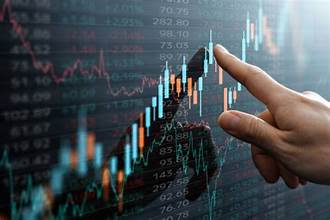

In [16]:
merged_test_df.shape

(41088, 17)

### Cleaning Data

The first step is to check the column data types and identify if there are any null values.

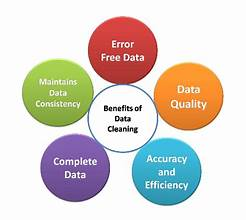

In [17]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

When some data is broken it best to talk to the owner itself for missing data or what he  nedds according  to that adjust the missing values...

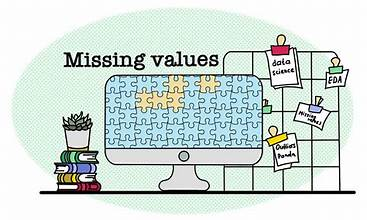

In [18]:
round(merged_df.describe().T, 2)

,count,mean,std,min,25%,50%,75%,max
Store,1017209.0,558.43,321.91,1.0,280.0,558.0,838.0,1115.0
DayOfWeek,1017209.0,4.00,2.00,1.0,2.0,4.0,6.0,7.0
Sales,1017209.0,5773.82,3849.93,0.0,3727.0,5744.0,7856.0,41551.0
Customers,1017209.0,633.15,464.41,0.0,405.0,609.0,837.0,7388.0
Open,1017209.0,0.83,0.38,0.0,1.0,1.0,1.0,1.0
Promo,1017209.0,0.38,0.49,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,1017209.0,0.18,0.38,0.0,0.0,0.0,0.0,1.0
CompetitionDistance,1014567.0,5430.09,7715.32,20.0,710.0,2330.0,6890.0,75860.0
CompetitionOpenSinceMonth,693861.0,7.22,3.21,1.0,4.0,8.0,10.0,12.0
CompetitionOpenSinceYear,693861.0,2008.69,5.99,1900.0,2006.0,2010.0,2013.0,2015.0


In [19]:
merged_df.duplicated().sum()

np.int64(0)

Let's also parse the date column

In [20]:
merged_df["Date"] = pd.to_datetime(merged_df["Date"])

In [21]:
merged_test_df["Date"] = pd.to_datetime(merged_test_df["Date"])

In [22]:
merged_df.Date.min(), merged_df.Date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [23]:
merged_test_df.Date.min(), merged_test_df.Date.max()

(Timestamp('2015-08-01 00:00:00'), Timestamp('2015-09-17 00:00:00'))

### Exploratory Data Analysis and Visualization

Objectives of exploratory data analysis:

- Study the distributions of individual columns (uniform, normal, exponential)
- Detect anomalies or errors in the data (e.g. missing/incorrect values)
- Study the relationship of target column with other columns (linear, non-linear etc.)
- Gather insights about the problem and the dataset
- Come up with ideas for preprocessing and feature engineering



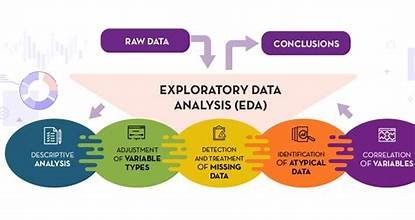

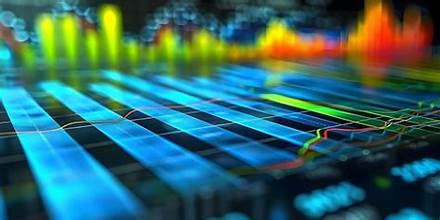

<Axes: xlabel='Sales', ylabel='Count'>

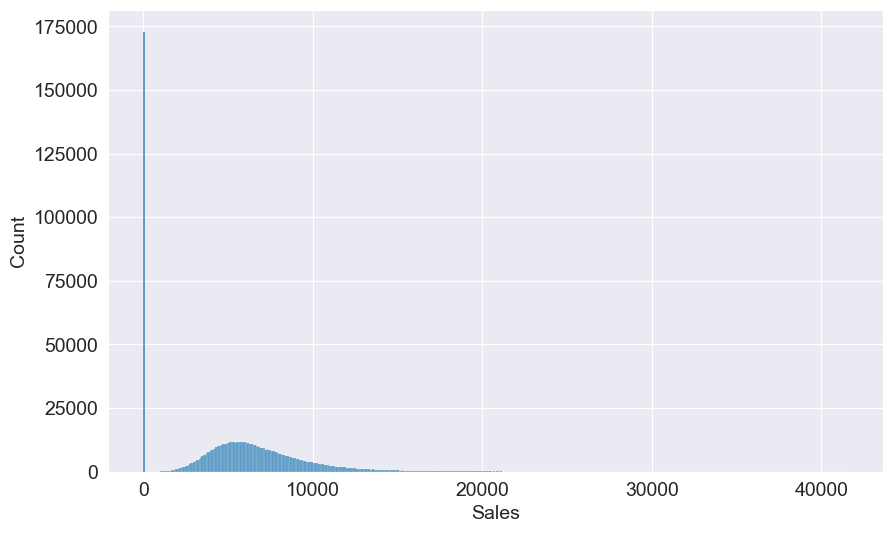

In [24]:
sns.histplot(data = merged_df, x = 'Sales')

Can you explain why the sales are 0 on so many dates? 

Let's check if this is because the store was closed.

In [25]:
merged_df.Open.value_counts()

Open
1    844392
0    172817
Name: count, dtype: int64

In [26]:
merged_df.value_counts('Open')

Open
1    844392
0    172817
Name: count, dtype: int64

In [27]:
merged_df.Sales.value_counts()

Sales
0        172871
5674        215
5558        197
5483        196
6214        195
          ...  
982           1
1173          1
1090          1
1338          1
18841         1
Name: count, Length: 21734, dtype: int64

In [28]:
merged_df = merged_df[merged_df.Open == 1].copy()

<Axes: xlabel='Sales', ylabel='Count'>

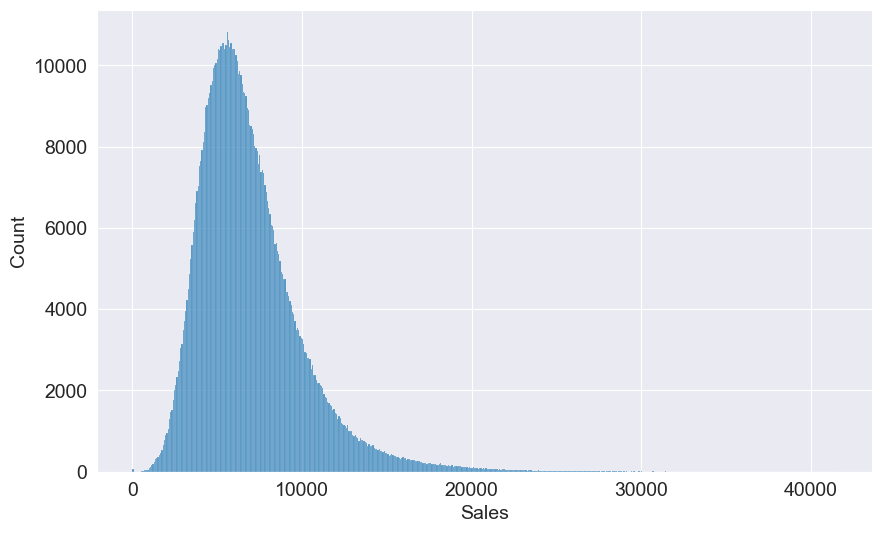

In [29]:
sns.histplot(data = merged_df, x = 'Sales')

Let's explore some other columns

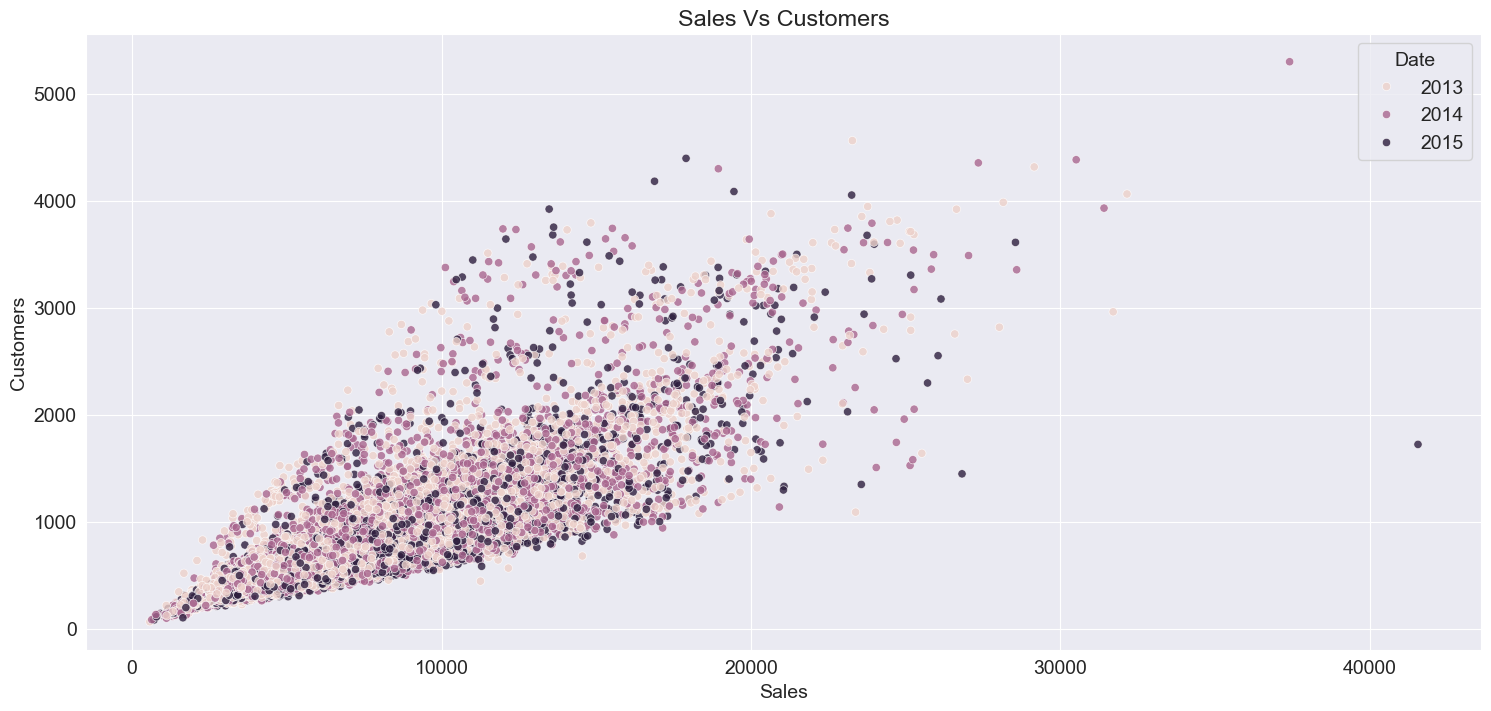

In [30]:
plt.figure(figsize=(18,8))
temp_df = merged_df.sample(40000)
sns.scatterplot(x=temp_df.Sales, y=temp_df.Customers, hue=temp_df.Date.dt.year, alpha=0.8)
plt.title("Sales Vs Customers")
plt.show()

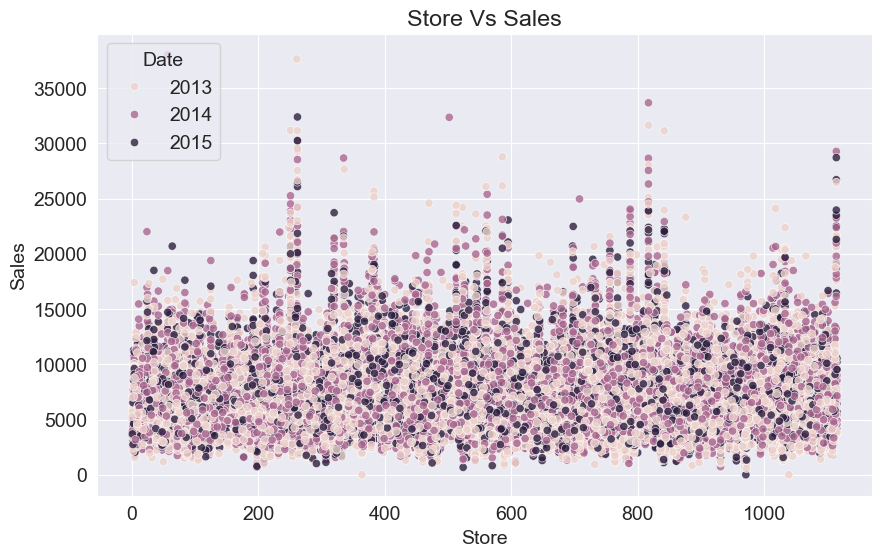

In [31]:
plt.Figure(figsize=(18,8))
temp_df = merged_df.sample(40000)
sns.scatterplot(x=temp_df.Store, y=temp_df.Sales, hue=temp_df.Date.dt.year, alpha=0.8)
plt.title("Store Vs Sales")
plt.show()

In [32]:
import plotly.express as px

temp_df = merged_df.sample(40000)

fig = px.scatter(
    temp_df,
    x="Store",
    y="Sales",
    color=temp_df["Date"].dt.year.astype(str),
    hover_data=["Date", "Sales", "Customers"]
)

fig.show()

<Axes: xlabel='DayOfWeek', ylabel='Sales'>

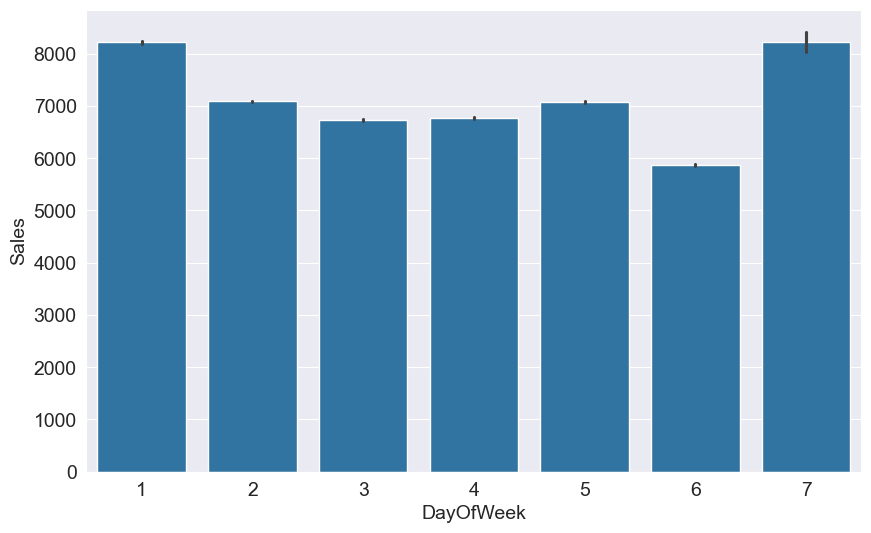

In [33]:
sns.barplot(data=merged_df, x='DayOfWeek', y='Sales')

In [34]:
import plotly.express as px

day_sales = merged_df.groupby('DayOfWeek')['Sales'].mean().reset_index()
fig = px.bar(
    day_sales,
    x='DayOfWeek',
    y='Sales',
    title='Average Sales by Day of Week',
    hover_data=['Sales']
)

fig.show()

<Axes: xlabel='Promo', ylabel='Sales'>

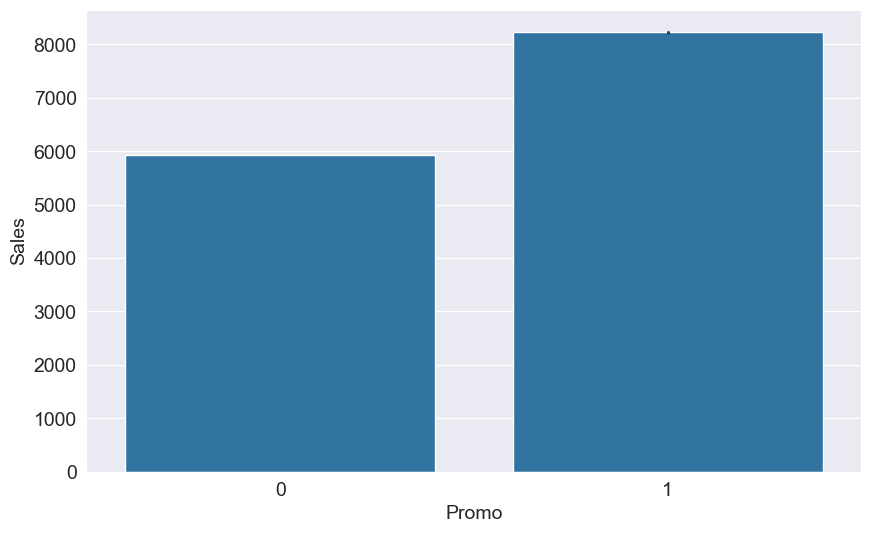

In [35]:
sns.barplot(data=merged_df, x='Promo', y='Sales')

In [36]:
import plotly.express as px

promo_sales = merged_df.groupby('Promo')['Sales'].mean().reset_index()
fig = px.bar(
    promo_sales,
    x='Promo',
    y='Sales',
    title='Average Sales by Promo',
    hover_data=['Sales']
)

fig.show()

In [37]:
# Correlate Sales only with numeric columns
merged_df.select_dtypes(include='number').corr()['Sales'].sort_values(ascending=False)

Sales                        1.000000
Customers                    0.823597
Promo                        0.368145
Promo2SinceWeek              0.095311
SchoolHoliday                0.038617
CompetitionOpenSinceYear     0.016101
Store                        0.007710
Promo2SinceYear             -0.034713
CompetitionDistance         -0.036396
CompetitionOpenSinceMonth   -0.043489
Promo2                      -0.127596
DayOfWeek                   -0.178736
Open                              NaN
Name: Sales, dtype: float64

Top numeric relationships with Sales (by absolute correlation):


,corr_with_sales
Customers,0.823597
Promo,0.368145
DayOfWeek,-0.178736
Promo2,-0.127596
Promo2SinceWeek,0.095311
CompetitionOpenSinceMonth,-0.043489
SchoolHoliday,0.038617
CompetitionDistance,-0.036396
Promo2SinceYear,-0.034713
CompetitionOpenSinceYear,0.016101


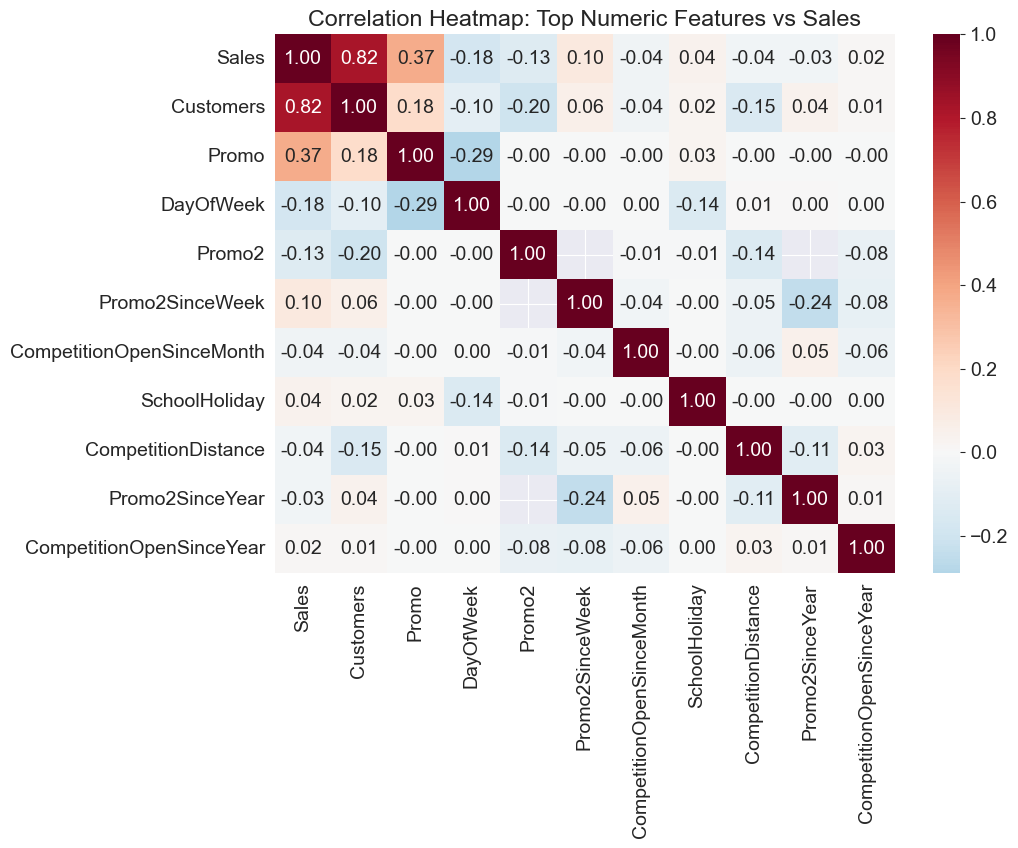


Category impact on Sales: StateHoliday


,mean,median,count
StateHoliday,,,
b,9887.889655,8423.0,145
c,9743.746479,8397.0,71
a,8487.471182,7556.0,694
0,6953.515034,6368.0,843482


C:\Users\SUDEB BAG\AppData\Local\Temp\ipykernel_20932\2036319236.py:55: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




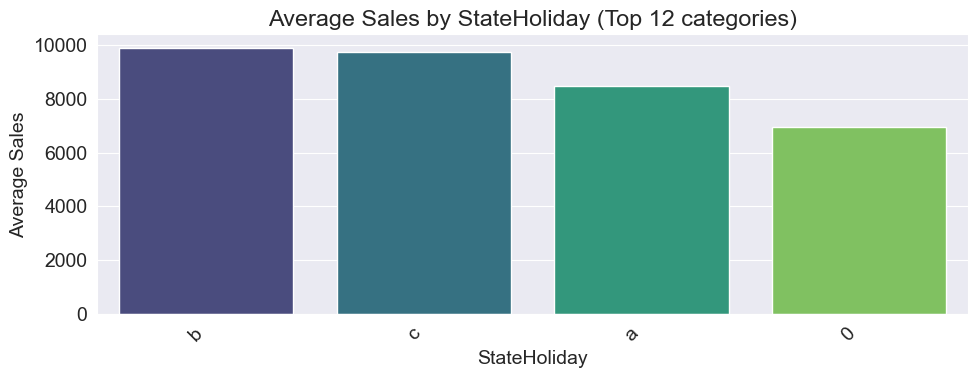


Category impact on Sales: StoreType


,mean,median,count
StoreType,,,
b,10231.407505,9130.0,15563
c,6932.512755,6407.0,112978
a,6925.167661,6285.0,457077
d,6822.141881,6395.0,258774


C:\Users\SUDEB BAG\AppData\Local\Temp\ipykernel_20932\2036319236.py:55: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




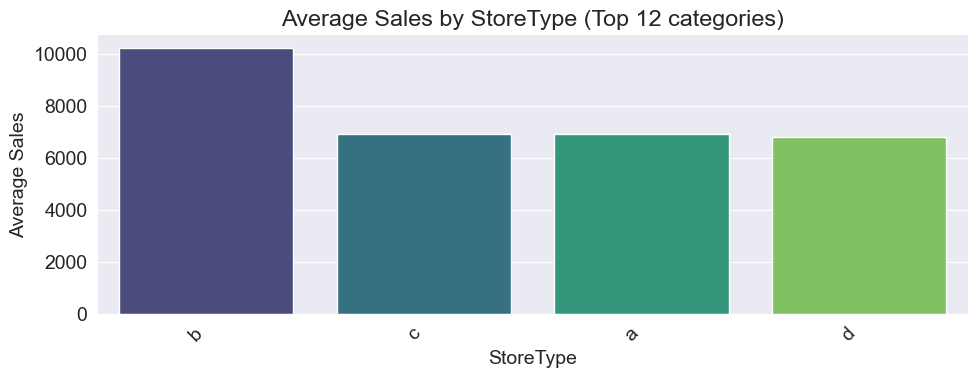


Category impact on Sales: Assortment


,mean,median,count
Assortment,,,
b,8639.346322,8081.0,8212
c,7300.526339,6675.0,391271
a,6621.017039,6082.0,444909


C:\Users\SUDEB BAG\AppData\Local\Temp\ipykernel_20932\2036319236.py:55: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




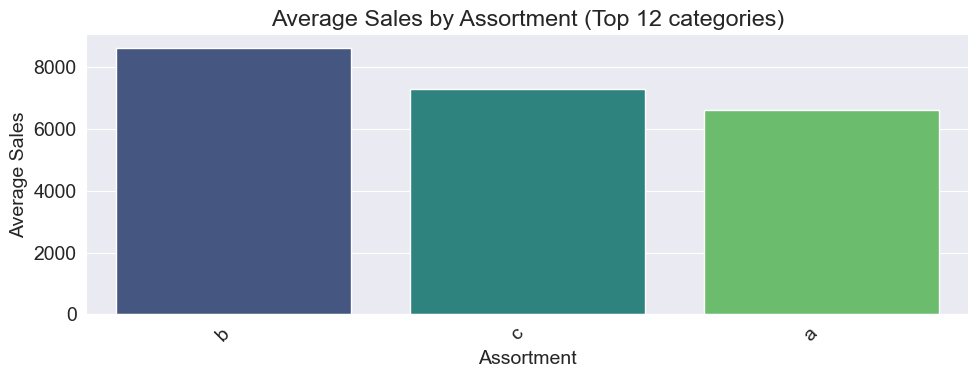


Category impact on Sales: PromoInterval


,mean,median,count
PromoInterval,,,
NaN,7350.557935,6685.0,423307
"Jan,Apr,Jul,Oct",6725.978932,6215.0,242411
"Feb,May,Aug,Nov",6426.907994,6002.0,98005
"Mar,Jun,Sept,Dec",6214.501209,5754.0,80669


C:\Users\SUDEB BAG\AppData\Local\Temp\ipykernel_20932\2036319236.py:55: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




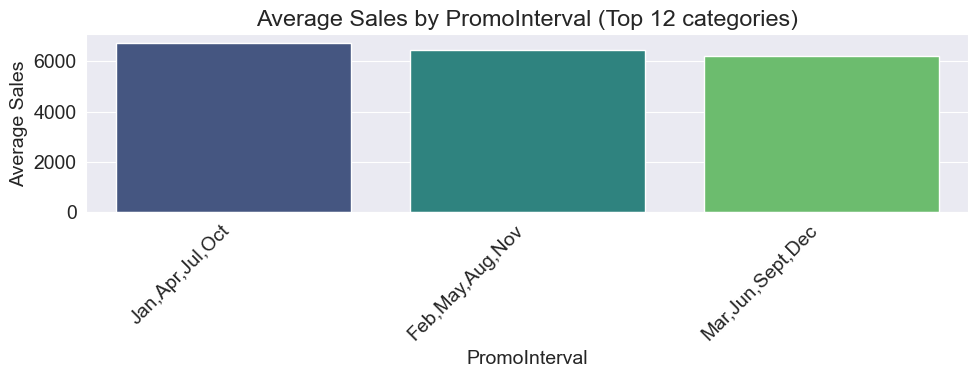

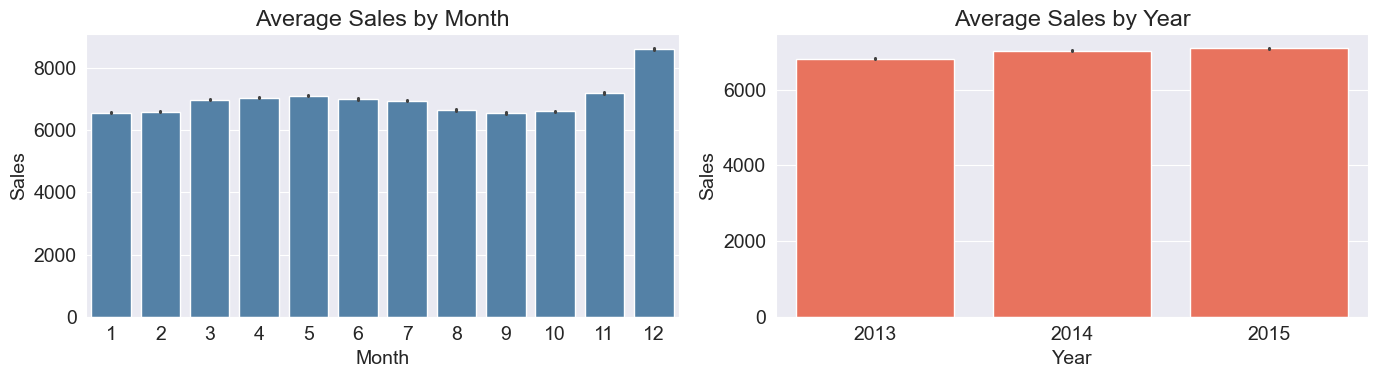

Analysis complete: numeric, categorical, and date-based relationships explored.


In [38]:
# EXERCISE: Analyze how other columns are related to Sales
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

target_col = 'Sales'

# 1) Numeric columns vs target (correlation)
numeric_cols = merged_df.select_dtypes(include='number').columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

num_corr = merged_df[[target_col] + numeric_cols].corr()[target_col].drop(target_col)
num_corr_sorted = num_corr.reindex(num_corr.abs().sort_values(ascending=False).index)

print('Top numeric relationships with Sales (by absolute correlation):')
display(num_corr_sorted.head(12).to_frame('corr_with_sales'))

# Heatmap for top numeric columns
top_num_cols = num_corr_sorted.head(10).index.tolist()
plt.figure(figsize=(10, 7))
sns.heatmap(
    merged_df[[target_col] + top_num_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0
 )
plt.title('Correlation Heatmap: Top Numeric Features vs Sales')
plt.show()

# 2) Categorical columns vs target (mean sales by category)
cat_cols = merged_df.select_dtypes(include=['object', 'category']).columns.tolist()

if not cat_cols:
    print('No categorical columns found for grouped analysis.')
else:
    # Keep only manageable cardinality columns for clear plots
    cat_cols = [c for c in cat_cols if merged_df[c].nunique(dropna=False) <= 20]

    if not cat_cols:
        print('Categorical columns have high cardinality; skipping category plots.')
    else:
        for col in cat_cols:
            summary = (
                merged_df.groupby(col, dropna=False)[target_col]
                .agg(['mean', 'median', 'count'])
                .sort_values('mean', ascending=False)
            )

            print(f'\nCategory impact on Sales: {col}')
            display(summary.head(12))

            plt.figure(figsize=(10, 4))
            sns.barplot(
                data=summary.reset_index().head(12),
                x=col,
                y='mean',
                palette='viridis'
            )
            plt.title(f'Average Sales by {col} (Top 12 categories)')
            plt.xticks(rotation=45, ha='right')
            plt.ylabel('Average Sales')
            plt.tight_layout()
            plt.show()

# 3) Date-derived feature relationships (if Date exists)
if 'Date' in merged_df.columns and np.issubdtype(merged_df['Date'].dtype, np.datetime64):
    date_df = merged_df.copy()
    date_df['Month'] = date_df['Date'].dt.month
    date_df['Year'] = date_df['Date'].dt.year

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.barplot(data=date_df, x='Month', y=target_col, estimator=np.mean, ax=axes[0], color='steelblue')
    axes[0].set_title('Average Sales by Month')

    sns.barplot(data=date_df, x='Year', y=target_col, estimator=np.mean, ax=axes[1], color='tomato')
    axes[1].set_title('Average Sales by Year')

    plt.tight_layout()
    plt.show()

print('Analysis complete: numeric, categorical, and date-based relationships explored.')

### Feature Engineering

Feature engineer is the process of creating new features (columns) by transforming/combining existing features or by incorporating data from external sources. 


For example, here are some features that can be extracted from the "Date" column:

1. Day of week
2. Day or month
3. Month
4. Year
5. Weekend/Weekday
6. Month/Quarter End


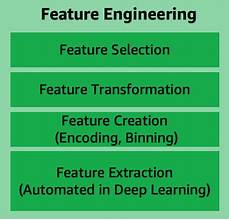

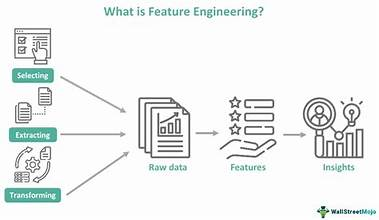

In [39]:
merged_df["Day"] = merged_df["Date"].dt.day
merged_df["Month"] = merged_df["Date"].dt.month 
merged_df["Year"] = merged_df["Date"].dt.year

In [40]:
merged_test_df['Day'] = merged_test_df.Date.dt.day
merged_test_df['Month'] = merged_test_df.Date.dt.month
merged_test_df['Year'] = merged_test_df.Date.dt.year

<Axes: xlabel='Year', ylabel='Sales'>

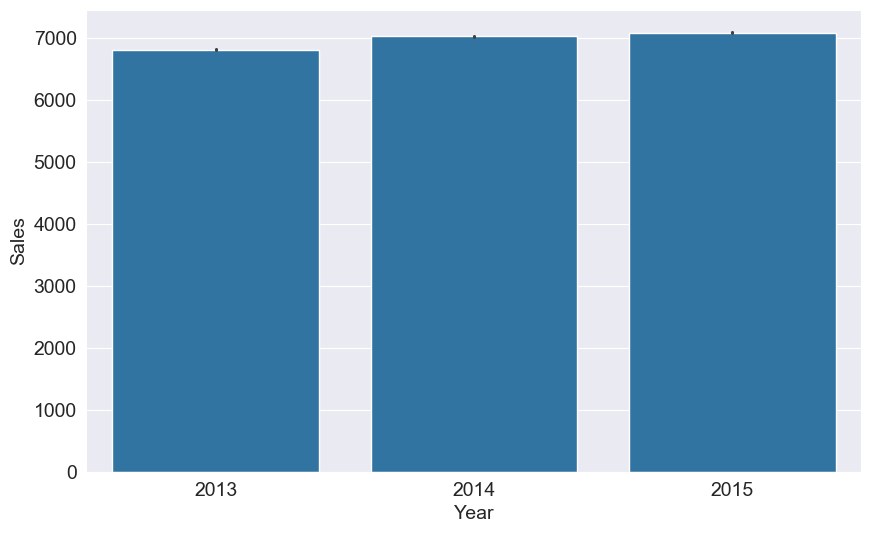

In [41]:
sns.barplot(data=merged_df, x='Year', y='Sales')

<Axes: xlabel='Month', ylabel='Sales'>

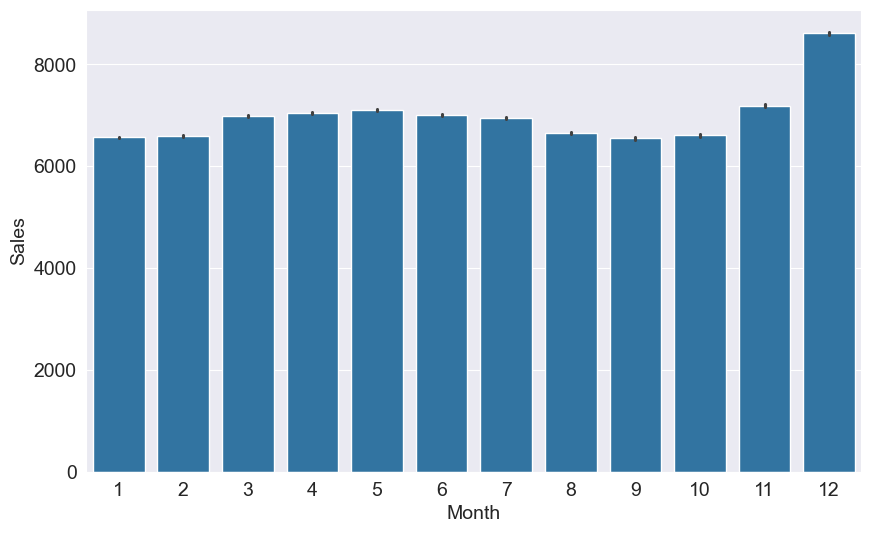

In [42]:
sns.barplot(data=merged_df, x='Month', y='Sales')



Using date information, we can also create new current columns like: 

1. Weather on each day
2. Whether the date was a public holiday
3. Whether the store was running a promotion on that day.


> **EXERCISE**: Create new columns using the above ideas.

In [43]:
# EXERCISE: Create new columns from date/public-holiday/promo ideas
df = merged_df.copy()

# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Basic date-derived columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend'] = (df['Date'].dt.dayofweek >= 5).astype(int)

# 1) Weather-like feature from date (proxy: season by month)
month_to_season = {
    12: 'winter', 1: 'winter', 2: 'winter',
    3: 'spring', 4: 'spring', 5: 'spring',
    6: 'summer', 7: 'summer', 8: 'summer',
    9: 'autumn', 10: 'autumn', 11: 'autumn'
}
df['Weather_SeasonProxy'] = df['Month'].map(month_to_season)

# 2) Public holiday flag from StateHoliday
df['IsPublicHoliday'] = (df['StateHoliday'].astype(str) != '0').astype(int)

# 3) Promotion flag from Promo
df['IsPromoRunning'] = (df['Promo'] == 1).astype(int)

# Optional interaction feature: promotion on holiday
df['PromoOnHoliday'] = (df['IsPromoRunning'] & df['IsPublicHoliday']).astype(int)

# Show created columns
new_cols = [
    'Date', 'Weather_SeasonProxy', 'IsPublicHoliday', 'IsPromoRunning',
    'PromoOnHoliday', 'Year', 'Month', 'WeekOfYear', 'IsWeekend'
 ]
display(df[new_cols].head(10))

# Quick distributions
print('Season proxy distribution:')
display(df['Weather_SeasonProxy'].value_counts())

print('IsPublicHoliday distribution:')
display(df['IsPublicHoliday'].value_counts())

print('IsPromoRunning distribution:')
display(df['IsPromoRunning'].value_counts())

# Save back for later modeling in notebook
merged_df = df

,Date,Weather_SeasonProxy,IsPublicHoliday,IsPromoRunning,PromoOnHoliday,Year,Month,WeekOfYear,IsWeekend
0,2015-07-31,summer,0,1,0,2015,7,31,0
1,2015-07-31,summer,0,1,0,2015,7,31,0
2,2015-07-31,summer,0,1,0,2015,7,31,0
3,2015-07-31,summer,0,1,0,2015,7,31,0
4,2015-07-31,summer,0,1,0,2015,7,31,0
5,2015-07-31,summer,0,1,0,2015,7,31,0
6,2015-07-31,summer,0,1,0,2015,7,31,0
7,2015-07-31,summer,0,1,0,2015,7,31,0
8,2015-07-31,summer,0,1,0,2015,7,31,0
9,2015-07-31,summer,0,1,0,2015,7,31,0


Season proxy distribution:


Weather_SeasonProxy
spring    247814
summer    222576
winter    216979
autumn    157023
Name: count, dtype: int64

IsPublicHoliday distribution:


IsPublicHoliday
0    843482
1       910
Name: count, dtype: int64

IsPromoRunning distribution:


IsPromoRunning
0    467496
1    376896
Name: count, dtype: int64

> **EXERCISE**: The features `Promo2`, `Promo2SinceWeek` etc. are not very useful in their current form, because they do not relate to the current date. How can you improve their representation?

In [44]:
# EXERCISE: Improve Promo2-related features using current row date
import os
import pandas as pd

# Rebuild required dataframes if kernel was restarted
try:
    _ = merged_df.shape
    _ = merged_test_df.shape
except NameError:
    train_path = './rossmann-store-sales/train.csv'
    test_path = './rossmann-store-sales/test.csv'
    store_path = './rossmann-store-sales/store.csv'

    if not (os.path.exists(train_path) and os.path.exists(test_path) and os.path.exists(store_path)):
        raise FileNotFoundError('Rossmann CSV files not found. Please run the data loading section first.')

    _ross_df = pd.read_csv(train_path, low_memory=False)
    _test_df = pd.read_csv(test_path, low_memory=False)
    _store_df = pd.read_csv(store_path)

    merged_df = _ross_df.merge(_store_df, on='Store', how='left')
    merged_test_df = _test_df.merge(_store_df, on='Store', how='left')

def add_promo2_date_features(df):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])

    # Build promo start date from Promo2SinceYear + Promo2SinceWeek (ISO week calendar)
    valid_start = (
        (df['Promo2'] == 1)
        & df['Promo2SinceYear'].notna()
        & df['Promo2SinceWeek'].notna()
    )

    promo_start_str = (
        df.loc[valid_start, 'Promo2SinceYear'].astype(int).astype(str)
        + '-W' + df.loc[valid_start, 'Promo2SinceWeek'].astype(int).astype(str).str.zfill(2)
        + '-1'  # Monday of ISO week
    )

    df['Promo2StartDate'] = pd.NaT
    df.loc[valid_start, 'Promo2StartDate'] = pd.to_datetime(
        promo_start_str,
        format='%G-W%V-%u',
        errors='coerce'
    )

    # Date-aware promo features
    df['WeeksSincePromo2Start'] = ((df['Date'] - df['Promo2StartDate']).dt.days / 7)
    df['WeeksSincePromo2Start'] = df['WeeksSincePromo2Start'].clip(lower=0).fillna(0).astype(int)

    # Active only if Promo2 exists and start date is in the past
    df['IsPromo2ActiveNow'] = (
        (df['Promo2'] == 1)
        & df['Promo2StartDate'].notna()
        & (df['Date'] >= df['Promo2StartDate'])
    ).astype(int)

    # Promo2 cycle month feature: whether current month is in promo interval schedule
    month_name_map = {
        1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
        5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
        9: 'Sept', 10: 'Oct', 11: 'Nov', 12: 'Dec'
    }
    current_month = df['Date'].dt.month.map(month_name_map)

    interval_str = df['PromoInterval'].fillna('').astype(str)
    df['IsPromo2Month'] = interval_str.str.split(',').combine(
        current_month,
        lambda months, m: int(m in months) if isinstance(months, list) and m is not None else 0
    )

    # Active promo month (stronger signal than raw Promo2 flag)
    df['IsPromo2RunningNow'] = (df['IsPromo2ActiveNow'] & df['IsPromo2Month']).astype(int)

    return df

# Apply to train/test
merged_df = add_promo2_date_features(merged_df)
merged_test_df = add_promo2_date_features(merged_test_df)

# Preview improved features
promo2_feature_cols = [
    'Date', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval',
    'Promo2StartDate', 'WeeksSincePromo2Start', 'IsPromo2ActiveNow',
    'IsPromo2Month', 'IsPromo2RunningNow'
 ]
display(merged_df[promo2_feature_cols].head(10))

print('Distribution of improved Promo2 features (train):')
display(
    merged_df[['IsPromo2ActiveNow', 'IsPromo2Month', 'IsPromo2RunningNow']]
    .agg(['mean', 'sum'])
    .rename(index={'mean': 'ratio', 'sum': 'count'})
)

,Date,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Promo2StartDate,WeeksSincePromo2Start,IsPromo2ActiveNow,IsPromo2Month,IsPromo2RunningNow
0,2015-07-31,0,NaN,NaN,NaN,NaT,0,0,0,0
1,2015-07-31,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2010-03-29,278,1,1,1
2,2015-07-31,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2011-04-04,225,1,1,1
3,2015-07-31,0,NaN,NaN,NaN,NaT,0,0,0,0
4,2015-07-31,0,NaN,NaN,NaN,NaT,0,0,0,0
5,2015-07-31,0,NaN,NaN,NaN,NaT,0,0,0,0
6,2015-07-31,0,NaN,NaN,NaN,NaT,0,0,0,0
7,2015-07-31,0,NaN,NaN,NaN,NaT,0,0,0,0
8,2015-07-31,0,NaN,NaN,NaN,NaT,0,0,0,0
9,2015-07-31,0,NaN,NaN,NaN,NaT,0,0,0,0


Distribution of improved Promo2 features (train):


,IsPromo2ActiveNow,IsPromo2Month,IsPromo2RunningNow
ratio,0.430879,0.171991,0.14967
count,363831.000000,145228.000000,126380.00000


## Step 4 - Create a training/test/validation split and prepare the data for training

<img src="https://i.imgur.com/XZ9aP10.png" width="640">

### Train/Test/Validation Split

The data already contains a test set, which contains over one month of data after the end of the training set. We can apply a similar strategy to create a validation set. We'll the last 25% of rows for the validation set, after ordering by date

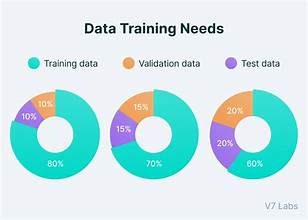

In [45]:
len(merged_df)

844392

In [46]:
train_size = int(.75 * len(merged_df))
train_size

633294

In [47]:
sorted_df = merged_df.sort_values('Date')
train_df, val_df = sorted_df[:train_size], sorted_df[train_size:]

In [48]:
len(train_df), len(val_df)

(633294, 211098)

In [49]:
train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,IsWeekend,Weather_SeasonProxy,IsPublicHoliday,IsPromoRunning,PromoOnHoliday,Promo2StartDate,WeeksSincePromo2Start,IsPromo2ActiveNow,IsPromo2Month,IsPromo2RunningNow
1017190,1097,2,2013-01-01,5961,1405,1,0,a,1,b,...,0,winter,1,0,0,NaT,0,0,0,0
1016179,85,2,2013-01-01,4220,619,1,0,a,1,b,...,0,winter,1,0,0,NaT,0,0,0,0
1016353,259,2,2013-01-01,6851,1444,1,0,a,1,b,...,0,winter,1,0,0,NaT,0,0,0,0
1016356,262,2,2013-01-01,17267,2875,1,0,a,1,b,...,0,winter,1,0,0,NaT,0,0,0,0
1016368,274,2,2013-01-01,3102,729,1,0,a,1,b,...,0,winter,1,0,0,2013-03-04,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256632,745,3,2014-12-10,6897,657,1,0,0,0,a,...,0,winter,0,0,0,2009-09-07,274,1,0,0
256642,756,3,2014-12-10,15736,2292,1,0,0,0,a,...,0,winter,0,0,0,2011-10-03,166,1,0,0
256634,747,3,2014-12-10,7444,608,1,0,0,0,c,...,0,winter,0,0,0,NaT,0,0,0,0
256633,746,3,2014-12-10,5207,474,1,0,0,0,d,...,0,winter,0,0,0,2011-08-29,171,1,1,1


In [50]:
train_df.Date.min(), train_df.Date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2014-12-10 00:00:00'))

In [51]:
val_df.Date.min(), val_df.Date.max()

(Timestamp('2014-12-10 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [52]:
merged_test_df.Date.min(), merged_test_df.Date.max()    

(Timestamp('2015-08-01 00:00:00'), Timestamp('2015-09-17 00:00:00'))

In [53]:
train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,IsWeekend,Weather_SeasonProxy,IsPublicHoliday,IsPromoRunning,PromoOnHoliday,Promo2StartDate,WeeksSincePromo2Start,IsPromo2ActiveNow,IsPromo2Month,IsPromo2RunningNow
1017190,1097,2,2013-01-01,5961,1405,1,0,a,1,b,...,0,winter,1,0,0,NaT,0,0,0,0
1016179,85,2,2013-01-01,4220,619,1,0,a,1,b,...,0,winter,1,0,0,NaT,0,0,0,0
1016353,259,2,2013-01-01,6851,1444,1,0,a,1,b,...,0,winter,1,0,0,NaT,0,0,0,0
1016356,262,2,2013-01-01,17267,2875,1,0,a,1,b,...,0,winter,1,0,0,NaT,0,0,0,0
1016368,274,2,2013-01-01,3102,729,1,0,a,1,b,...,0,winter,1,0,0,2013-03-04,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256632,745,3,2014-12-10,6897,657,1,0,0,0,a,...,0,winter,0,0,0,2009-09-07,274,1,0,0
256642,756,3,2014-12-10,15736,2292,1,0,0,0,a,...,0,winter,0,0,0,2011-10-03,166,1,0,0
256634,747,3,2014-12-10,7444,608,1,0,0,0,c,...,0,winter,0,0,0,NaT,0,0,0,0
256633,746,3,2014-12-10,5207,474,1,0,0,0,d,...,0,winter,0,0,0,2011-08-29,171,1,1,1


In [54]:
train_df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Day', 'Month', 'Year',
       'WeekOfYear', 'IsWeekend', 'Weather_SeasonProxy', 'IsPublicHoliday',
       'IsPromoRunning', 'PromoOnHoliday', 'Promo2StartDate',
       'WeeksSincePromo2Start', 'IsPromo2ActiveNow', 'IsPromo2Month',
       'IsPromo2RunningNow'],
      dtype='object')

### Input and Target columns

Let's also identify input and target columns. Note that we can't use the no. of customers as an input, because this information isn't available beforehand. Also, we needn't use all the available columns, we can start out with just a small subset.

In [55]:
input_cols = ['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'StoreType', 'Assortment', 'Day', 'Month', 'Year']

In [56]:
target_col = 'Sales'

In [57]:
merged_df[input_cols].nunique()

Store           1115
DayOfWeek          7
Promo              2
StateHoliday       4
StoreType          4
Assortment         3
Day               31
Month             12
Year               3
dtype: int64

In [58]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

In [59]:
val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

In [60]:
test_inputs = merged_test_df[input_cols].copy()
# Test data does not have targets

Note that some columns can be treated as both numeric and categorical, and it's up t you to decide how you want to deal with them.

In [61]:
numeric_cols = ['Store', 'Day', 'Month', 'Year']
categorical_cols = ['DayOfWeek', 'Promo', 'StateHoliday', 'StoreType', 'Assortment']

### Imputation, Scaling and Encode

Let's impute missing data from numeric columns and scale the values to the $(0, 1)$ range. 

In [62]:
from sklearn.impute import SimpleImputer

In [63]:
imputer = SimpleImputer(strategy='median').fit(train_inputs[numeric_cols])

In [64]:
train_inputs[numeric_cols] = imputer.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = imputer.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = imputer.transform(test_inputs[numeric_cols])

Note that this step wasn't necessary for the store sales dataset, as there were no null values. Also, we can apply a different imputation strategy to different columns depending on their distributions (e.g. mean for normally distribute and median for exponentially distributed).

Let's also scale the values to the $(0, 1)$ range.

In [65]:
from sklearn.preprocessing import MinMaxScaler

In [66]:
scaler = MinMaxScaler().fit(train_inputs[numeric_cols])

In [67]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])
test_inputs[numeric_cols] = scaler.transform(test_inputs[numeric_cols])

Finally, let's encode categorical columns as one-hot vectors.

In [68]:
from sklearn.preprocessing import OneHotEncoder

In [69]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(train_inputs[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

In [70]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])
test_inputs[encoded_cols] = encoder.transform(test_inputs[categorical_cols])

Let's now extract out the numeric data.

In [71]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]
X_test = test_inputs[numeric_cols + encoded_cols]

In [72]:
X_train

,Store,Day,Month,Year,DayOfWeek_1,DayOfWeek_2,DayOfWeek_3,DayOfWeek_4,DayOfWeek_5,DayOfWeek_6,...,StateHoliday_a,StateHoliday_b,StateHoliday_c,StoreType_a,StoreType_b,StoreType_c,StoreType_d,Assortment_a,Assortment_b,Assortment_c
1017190,0.983842,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1016179,0.075404,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1016353,0.231598,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1016356,0.234291,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1016368,0.245063,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256632,0.667864,0.3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
256642,0.677738,0.3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
256634,0.669659,0.3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
256633,0.668761,0.3,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


## Step 5 - Create quick & easy baseline models to benchmark future models

<img src="https://i.imgur.com/1DLgiEz.png" width="640">

A quick baseline model helps establish the minimum score any ML model you train should achieve.


### Fixed/Random Guess

Let's define a model that always returns the mean value of Sales as the prediction.

In [73]:
# Baseline predictor: always predict average sales
def return_mean(inputs):
    return np.full(len(inputs), merged_df.Sales.mean())

train_preds = return_mean(X_train)
val_preds = return_mean(X_val)

from sklearn.metrics import mean_squared_error

# Compatible RMSE (works across sklearn versions)
train_rmse = np.sqrt(mean_squared_error(train_targets, train_preds))
val_rmse = np.sqrt(mean_squared_error(val_targets, val_preds))
print('Train RMSE:', train_rmse)
print('Val RMSE  :', val_rmse)

# RMSPE implementation
def rmspe(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Avoid divide-by-zero; common practice for RMSPE
    non_zero = y_true != 0
    return np.sqrt(np.mean(np.square((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])))

print('Train RMSPE:', rmspe(train_targets, train_preds))
print('Val RMSPE  :', rmspe(val_targets, val_preds))

Train RMSE: 3082.450443277419
Val RMSE  : 3168.6033635047716
Train RMSPE: 0.6516828711491892
Val RMSPE  : 0.5800038814833266


In [74]:
# EXERCISE: Baseline using last year's same-month average sales per store
import numpy as np
import pandas as pd

# Use train_df (preferred) to build history; fallback to merged_df if needed
history_df = train_df.copy() if 'train_df' in globals() else merged_df.copy()
history_df['Date'] = pd.to_datetime(history_df['Date'])
history_df['Year'] = history_df['Date'].dt.year
history_df['Month'] = history_df['Date'].dt.month

# Lookup table: (Store, Year, Month) -> mean sales
store_year_month_mean = (
    history_df.groupby(['Store', 'Year', 'Month'])['Sales']
    .mean()
    .to_dict()
 )

# Useful fallback means
store_mean = history_df.groupby('Store')['Sales'].mean().to_dict()
global_mean = history_df['Sales'].mean()

def predict_last_year_month_avg(inputs):
    # Work on copy to avoid side effects
    df = inputs.copy()

    # Ensure Month/Year are present
    if 'Month' not in df.columns or 'Year' not in df.columns:
        if 'Date' in df.columns:
            df['Date'] = pd.to_datetime(df['Date'])
            df['Month'] = df['Date'].dt.month
            df['Year'] = df['Date'].dt.year
        else:
            raise ValueError("Inputs must contain either ['Month','Year'] or 'Date'.")

    preds = []
    for _, row in df.iterrows():
        # Rule 1: if closed, predict 0
        if 'Open' in df.columns and row['Open'] == 0:
            preds.append(0.0)
            continue

        store = int(row['Store'])
        month = int(row['Month'])
        prev_year = int(row['Year']) - 1

        # Rule 2: if open, predict avg sales of same store+month in previous year
        pred = store_year_month_mean.get((store, prev_year, month))

        # Graceful fallback if previous-year data is missing
        if pred is None:
            pred = store_mean.get(store, global_mean)

        preds.append(float(pred))

    return np.array(preds)

# Generate predictions
train_preds_lym = predict_last_year_month_avg(X_train)
val_preds_lym = predict_last_year_month_avg(X_val)

# RMSPE
def rmspe_metric(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    non_zero = y_true != 0
    return np.sqrt(np.mean(np.square((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])))

train_rmspe_lym = rmspe_metric(train_targets, train_preds_lym)
val_rmspe_lym = rmspe_metric(val_targets, val_preds_lym)

print('Train RMSPE (last-year-month strategy):', train_rmspe_lym)
print('Validation RMSPE (last-year-month strategy):', val_rmspe_lym)

Train RMSPE (last-year-month strategy): 0.6400778834393924
Validation RMSPE (last-year-month strategy): 0.5701581016045784


The model is off by about $3000 on average.

Let's try another model, which makes a random guess between the lowest and highest sale.

In [75]:
def guess_random(inputs):
    lo, hi = merged_df.Sales.min(), merged_df.Sales.max()
    return np.random.random(len(inputs)) * (hi - lo) + lo

In [76]:
train_preds = guess_random(X_train)
train_preds

array([ 4426.1717734 , 36862.78445452, 25039.03336514, ...,
       36628.20991419, 27892.87582724, 33361.46309586], shape=(633294,))

In [77]:
# Version-compatible RMSE for random baseline
np.sqrt(mean_squared_error(train_targets, train_preds))

np.float64(18604.94112553453)

In [78]:
np.sqrt(mean_squared_error(guess_random(X_val), val_targets))

np.float64(18415.837582246495)

### Baseline ML model

Let's train a simple `LinearRegression` model, with no customization.

In [79]:
from sklearn.linear_model import LinearRegression

In [80]:
linreg = LinearRegression()

In [81]:
linreg.fit(X_train, train_targets)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


`model.fit` uses the following workflow for training the model ([source](https://www.deepnetts.com/blog/from-basic-machine-learning-to-deep-learning-in-5-minutes.html)):

1. We initialize a model with random parameters (weights & biases).
2. We pass some inputs into the model to obtain predictions.
3. We compare the model's predictions with the actual targets using the loss function.  
4. We use an optimization technique (like least squares, gradient descent etc.) to reduce the loss by adjusting the weights & biases of the model
5. We repeat steps 1 to 4 till the predictions from the model are good enough.


<img src="https://www.deepnetts.com/blog/wp-content/uploads/2019/02/SupervisedLearning.png" width="480">


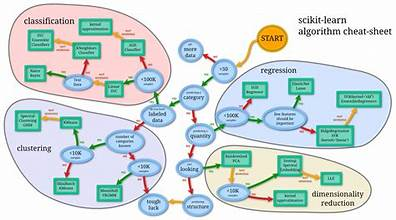